# Lab 02: Linear Regression

## Objectives:

- To clearly explain each stage of the ML pipeline
- To train and evaluate linear regression models
- To interpret model coefficients and intercepts
- To compare single-feature vs multi-feature regression models

## Theory:
### Regression:
Regression in AI is a supervised learning technique that predicts continuous numerical outcomes by analyzing the relationship between independent input variables and a dependent target variable.
 
So basically, it is about trying to find the relationship between variables.

#### Linear Regression:
Linear Regression is a supervised machine learning algorithm that learns from the labelled datasets and uses the relationship between data points to draw a straight line through all them.
 
The linear regression line is used to predict future values.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Task 1: Simple Linear Regression (Single Feature)

**Problem Statement:** Build a simple linear regression model using only the **housing_median_age** feature to predict **median_house_value**.

This task demonstrates the fundamental principles of linear regression by examining the relationship between a single predictor and the outcome variable.

## Step 1: Data Retrieval and Collection

The first step in any machine learning project is to acquire and explore the dataset. We load the 'housing.csv' dataset and examine its structure:

We learned that there are in total 10 features and 20640 observations.

In [30]:
# Load the California Housing dataset
housing_df = pd.read_csv("housing.csv")

# Display basic information about the dataset
print("Dataset Shape:", housing_df.shape)
print("\nColumn Names (Features):")
print(housing_df.columns.tolist())

Dataset Shape: (20640, 10)

Column Names (Features):
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']


In [31]:
# Display dataset information including data types and non-null counts
housing_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


So, in the total_bedroom feature. there are only 20433 observation values that are not null out of 20640.

In [32]:
# Display first few rows of the dataset
housing_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Step 2: Data Cleaning

Data quality is essential for reliable model performance. In this step, we identify and handle missing values.

Here, we simply remove the tuple containing null value of any feature. So, after the data cleaning, there must be 20433 observations in total containing not null values for all features.

In [33]:
# Check for missing values in each column
missing_values = housing_df.isna().sum().sort_values(ascending=False)
print("Missing Values per Column:")
print(missing_values)

Missing Values per Column:
total_bedrooms        207
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [34]:
# Remove rows with missing values
print(f"Dataset size before removing nulls: {len(housing_df)}")
housing_df = housing_df.dropna()
print(f"Dataset size after removing nulls: {len(housing_df)}")

# Verify that missing values have been handled
print("\nMissing values after removal:")
print(housing_df.isna().sum().sort_values(ascending=False).head())

Dataset size before removing nulls: 20640
Dataset size after removing nulls: 20433

Missing values after removal:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
dtype: int64


In [35]:
# Display dataset information including data types and non-null counts
housing_df.info()

<class 'pandas.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


## Step 3: Feature Design

For simple linear regression, we select a single input feature:

- **Input Feature (X):** `housing_median_age` - the median age of houses in a district
- **Target Variable (y):** `median_house_value` - the price we want to predict

**Why housing_median_age?**
- It's a numerical feature that may have a relationship with house prices
- Older/newer neighborhoods might have different property valuations
- Single-feature models are highly interpretable with just two parameters (slope and intercept)

In [36]:
# Select feature and target for simple linear regression
X_simple = housing_df[["housing_median_age"]]  # Must be 2D for sklearn
y_simple = housing_df["median_house_value"]

print("Feature shape:", X_simple.shape)
print("Target shape:", y_simple.shape)
print("\nFirst 5 samples:")
print(pd.concat([X_simple.head(), y_simple.head()], axis=1))

Feature shape: (20433, 1)
Target shape: (20433,)

First 5 samples:
   housing_median_age  median_house_value
0                41.0            452600.0
1                21.0            358500.0
2                52.0            352100.0
3                52.0            341300.0
4                52.0            342200.0


## Step 4: Algorithm Selection

We choose **Linear Regression** for this task because:

- **Continuous Target:** The target variable (median_house_value) is continuous, making regression appropriate
- **Interpretability:** Linear regression provides clear, interpretable coefficients
- **Simplicity:** It serves as a good baseline model before trying more complex algorithms
- **Efficiency:** Computationally inexpensive with a closed-form solution

**Mathematical Model:**
$$\hat{y} = \beta_1 x + \beta_0$$

Where:
- $\hat{y}$ = predicted house value
- $x$ = housing median age
- $\beta_1$ = coefficient (slope)
- $\beta_0$ = intercept

## Step 5: Loss Function Selection

We use **Mean Squared Error (MSE)** as our loss function:

$$MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

**What MSE measures:**
- The average of the squared differences between actual ($y_i$) and predicted ($\hat{y}_i$) values
- Squaring ensures all errors are positive and penalizes larger errors more heavily
- Lower MSE indicates better model performance
- Standard metric for regression tasks enabling fair comparison between models

## Understanding Gradient Descent

**Gradient Descent** is the backbone of the learning process for various algorithms, including linear regression. It is a fundamental optimization technique used to minimize the cost function by **iteratively adjusting the model parameters to reduce the difference between predicted and actual values**.

### The Cost Function

Our goal is to find parameters $w$ and $b$ such that $\hat{y}^{(i)}$ is close to $y^{(i)}$ for all data points. The cost function measures this:

$$J(w,b) = \frac{1}{2m} \sum_{i=1}^{m}(\hat{y}^{(i)} - y^{(i)})^2 = \frac{1}{2m} \sum_{i=1}^{m}(wx^{(i)} + b - y^{(i)})^2$$

Where:
- $m$ = number of training examples
- $\hat{y}^{(i)}$ = predicted value for the $i$-th example
- $y^{(i)}$ = actual value for the $i$-th example

### The Gradient Descent Algorithm

The algorithm iteratively updates parameters to minimize $J(w,b)$:

1. **Initialize parameters:** $w := 0, \quad b := 0$

2. **Repeat until convergence:**
   - Compute gradients:
     - $\frac{\partial J}{\partial w} = \frac{1}{m} \sum_{i=1}^{m}(wx^{(i)} + b - y^{(i)}) \cdot x^{(i)}$
     - $\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m}(wx^{(i)} + b - y^{(i)})$
   
   - Update parameters:
     - $w := w - \alpha \frac{\partial J}{\partial w}$
     - $b := b - \alpha \frac{\partial J}{\partial b}$

3. **Return optimized parameters:** $w, b$

Where $\alpha$ is the **learning rate** - a hyperparameter that controls how big of a step we take in each iteration.

In [63]:
# Implementing the cost function
import numpy as np
from sklearn.preprocessing import StandardScaler

def compute_cost(X, y, theta):
    """
    Compute the Mean Squared Error cost function.
    
    Parameters:
    - X: Feature matrix with intercept column (m x n)
    - y: Target values (m,)
    - theta: Parameters [b, w1, w2, ...] (n,)
    
    Returns:
    - cost: The MSE cost value
    """
    m = len(y)
    predictions = np.matmul(X, theta)
    cost = np.sum(np.square(predictions - y)) / (2 * m)
    return cost

# Prepare data for gradient descent demonstration
# Feature normalization is crucial for gradient descent to converge properly
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X_train_simple.values)
y_scaled = scaler_y.fit_transform(y_train_simple.values.reshape(-1, 1)).flatten()

# Add intercept column (column of 1s) to feature matrix
X_gd = np.column_stack((np.ones(len(X_scaled)), X_scaled))
y_gd = y_scaled

# Initialize theta with zeros
theta_init = np.zeros(2)
initial_cost = compute_cost(X_gd, y_gd, theta_init)

print("Note: Features and target are normalized for gradient descent to converge properly")
print(f"\nInitial theta: {theta_init}")
print(f"Initial cost with zero parameters: {initial_cost:.4f}")

Note: Features and target are normalized for gradient descent to converge properly

Initial theta: [0. 0.]
Initial cost with zero parameters: 0.5000


In [64]:
# Implementing Gradient Descent for Single Variable Linear Regression
def gradient_descent(X, y, alpha, iterations):
    """
    Perform gradient descent to learn theta parameters.
    
    Parameters:
    - X: Feature matrix with intercept column (m x n)
    - y: Target values (m,)
    - alpha: Learning rate
    - iterations: Number of iterations
    
    Returns:
    - theta: Optimized parameters
    - cost_history: Cost at each iteration
    """
    theta = np.zeros(X.shape[1])
    m = len(y)
    cost_history = []
    
    for i in range(iterations):
        # Compute predictions
        predictions = np.dot(X, theta)
        
        # Compute gradients
        gradient_b = (1/m) * np.sum(predictions - y)
        gradient_w = (1/m) * np.sum((predictions - y) * X[:, 1])
        
        # Update parameters simultaneously
        theta[0] = theta[0] - alpha * gradient_b
        theta[1] = theta[1] - alpha * gradient_w
        
        # Store cost for visualization
        cost_history.append(compute_cost(X, y, theta))
    
    return theta, cost_history

# Run gradient descent with normalized data
alpha = 0.1  # Learning rate
iterations = 1000

theta_gd, cost_history = gradient_descent(X_gd, y_gd, alpha, iterations)
final_cost = compute_cost(X_gd, y_gd, theta_gd)

print(f"Learning rate (α): {alpha}")
print(f"Number of iterations: {iterations}")
print(f"\nOptimized parameters (normalized scale):")
print(f"  Intercept (b): {theta_gd[0]:.6f}")
print(f"  Coefficient (w): {theta_gd[1]:.6f}")
print(f"\nFinal cost: {final_cost:.6f}")

Learning rate (α): 0.1
Number of iterations: 1000

Optimized parameters (normalized scale):
  Intercept (b): -0.000000
  Coefficient (w): 0.104041

Final cost: 0.494588


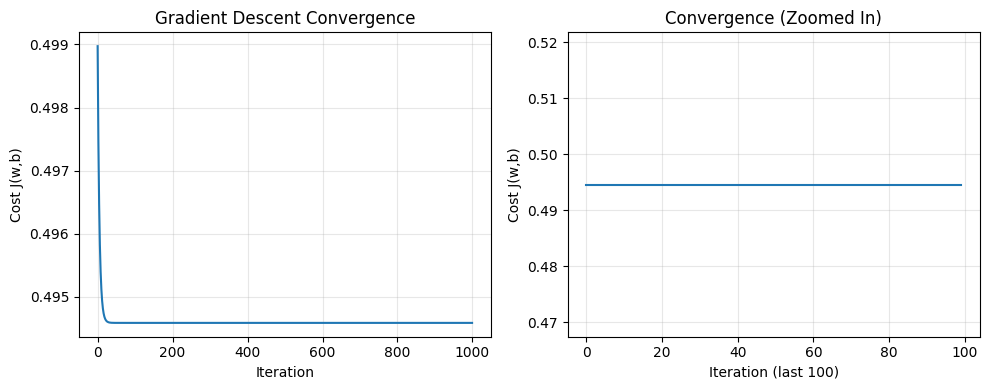

Cost reduction: 0.50 → 0.49


In [65]:
# Visualize the cost function convergence
plt.figure(figsize=(10, 4))

# Plot 1: Cost over iterations
plt.subplot(1, 2, 1)
plt.plot(cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost J(w,b)')
plt.title('Gradient Descent Convergence')
plt.grid(True, alpha=0.3)

# Plot 2: Cost over last 100 iterations (zoomed in)
plt.subplot(1, 2, 2)
plt.plot(cost_history[-100:])
plt.xlabel('Iteration (last 100)')
plt.ylabel('Cost J(w,b)')
plt.title('Convergence (Zoomed In)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Cost reduction: {cost_history[0]:,.2f} → {cost_history[-1]:,.2f}")

### Comparing Gradient Descent with sklearn's LinearRegression

Scikit-learn's `LinearRegression` uses the **Normal Equation** (closed-form solution) rather than gradient descent:

$$\theta = (X^TX)^{-1}X^Ty$$

Both methods find the optimal parameters, but:
- **Gradient Descent:** Iterative, works well with large datasets, requires tuning learning rate
- **Normal Equation:** Direct computation, can be slow for very large feature sets, no hyperparameters to tune

In [62]:
# Compare our gradient descent results with sklearn
# Transform gradient descent parameters back to original scale
w_original = theta_gd[1] * scaler_y.scale_[0] / scaler_X.scale_[0]
b_original = scaler_y.mean_[0] + theta_gd[0] * scaler_y.scale_[0] - w_original * scaler_X.mean_[0]

# Fit sklearn model for comparison
sklearn_model_gd = LinearRegression()
sklearn_model_gd.fit(X_train_simple, y_train_simple)

print("=== Parameter Comparison ===")
print(f"\nGradient Descent (converted to original scale):")
print(f"  Intercept (b): {b_original:,.2f}")
print(f"  Coefficient (w): {w_original:,.2f}")

print(f"\nScikit-learn (Normal Equation):")
print(f"  Intercept (b): {sklearn_model_gd.intercept_:,.2f}")
print(f"  Coefficient (w): {sklearn_model_gd.coef_[0]:,.2f}")

print(f"\nDifference (should be very small):")
print(f"  Intercept diff: {abs(b_original - sklearn_model_gd.intercept_):,.2f}")
print(f"  Coefficient diff: {abs(w_original - sklearn_model_gd.coef_[0]):,.2f}")

=== Parameter Comparison ===

Gradient Descent (converted to original scale):
  Intercept (b): 179,409.76
  Coefficient (w): 951.76

Scikit-learn (Normal Equation):
  Intercept (b): 179,409.76
  Coefficient (w): 951.76

Difference (should be very small):
  Intercept diff: 0.00
  Coefficient diff: 0.00


## Step 6: Model Learning (Training)

The training process involves:
1. **Data Splitting:** 80% training, 20% testing (standard practice)
2. **Model Fitting:** The algorithm learns optimal coefficients by minimizing MSE on training data

The `random_state=42` ensures reproducibility of results.

In [37]:
# Split data into training and testing sets (80-20 split)
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)

print("Training set size:", X_train_simple.shape[0])
print("Testing set size:", X_test_simple.shape[0])

Training set size: 16346
Testing set size: 4087


In [38]:
# Create and train the linear regression model
simple_model = LinearRegression()
simple_model.fit(X_train_simple, y_train_simple)

print("Model trained successfully!")
print("Model:", simple_model)

Model trained successfully!
Model: LinearRegression()


## Step 7: Model Evaluation

We evaluate the model using:
1. **Mean Squared Error (MSE):** Measures average squared prediction error
2. **R² Score (Coefficient of Determination):** Proportion of variance explained by the model
   - R² = 1: Perfect predictions
   - R² = 0: Model performs no better than predicting the mean
   - R² < 0: Model performs worse than the mean baseline

In [39]:
# Make predictions on test set
y_pred_simple = simple_model.predict(X_test_simple)

# Calculate evaluation metrics
mse_simple = mean_squared_error(y_test_simple, y_pred_simple)
r2_simple = r2_score(y_test_simple, y_pred_simple)

print("=== Task 1: Simple Linear Regression Results ===")
print(f"Mean Squared Error (MSE): {mse_simple:,.2f}")
print(f"R² Score: {r2_simple:.4f}")

=== Task 1: Simple Linear Regression Results ===
Mean Squared Error (MSE): 13,495,246,619.23
R² Score: 0.0132


## Model Interpretation (Mandatory)

Understanding the learned parameters helps interpret how the model makes predictions.

In [66]:
# Extract and display model coefficients (weights and bias)
coefficient_simple = simple_model.coef_[0]
intercept_simple = simple_model.intercept_

print("=" * 50)
print("TASK 1: WEIGHTS AND BIAS (Simple Linear Regression)")
print("=" * 50)
print(f"\nBias (Intercept, β₀): {intercept_simple:,.2f}")
print(f"Weight (Coefficient, β₁): {coefficient_simple:,.2f}")
print(f"\nFeature: housing_median_age")
print(f"\nPrediction Equation:")
print(f"  ŷ = {coefficient_simple:.2f} × housing_median_age + {intercept_simple:.2f}")

TASK 1: WEIGHTS AND BIAS (Simple Linear Regression)

Bias (Intercept, β₀): 179,409.76
Weight (Coefficient, β₁): 951.76

Feature: housing_median_age

Prediction Equation:
  ŷ = 951.76 × housing_median_age + 179409.76


### Interpretation of Results:

**Coefficient (Slope) Meaning:**
- The coefficient represents the expected change in `median_house_value` for each one-year increase in `housing_median_age`
- A positive coefficient indicates that older housing districts tend to have higher prices
- This could reflect that older neighborhoods are in more established, desirable locations

**Intercept Meaning:**
- The intercept represents the predicted house value when `housing_median_age` equals zero
- While not realistic (no houses have age 0), it serves as the mathematical starting point for the regression line

**Model Limitations:**
- The low R² score indicates that `housing_median_age` alone explains very little of the variance in house prices
- Housing prices depend on many other factors (location, income levels, property features) not captured in this simple model

## Extra: Visualizations

### Visualization 1: Scatter Plot with Regression Line

d:\git\ailab\lab_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


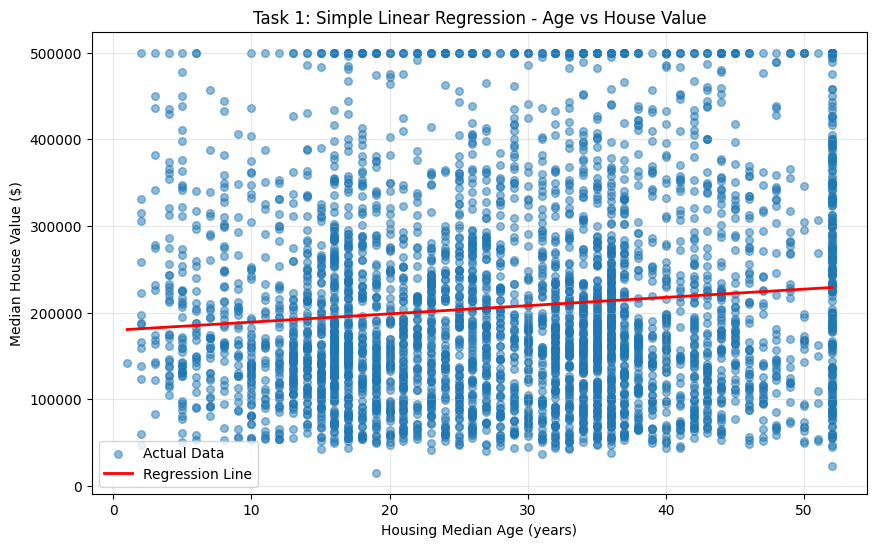

In [41]:
# Visualization 1: Scatter plot with regression line
plt.figure(figsize=(10, 6))
plt.scatter(X_test_simple, y_test_simple, alpha=0.5, s=30, label='Actual Data')

# Create regression line
X_sorted = np.sort(X_test_simple["housing_median_age"].values).reshape(-1, 1)
y_line = simple_model.predict(X_sorted)
plt.plot(X_sorted, y_line, color='red', linewidth=2, label='Regression Line')

plt.xlabel("Housing Median Age (years)")
plt.ylabel("Median House Value ($)")
plt.title("Task 1: Simple Linear Regression - Age vs House Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Visualization 2: Predicted vs Actual Values

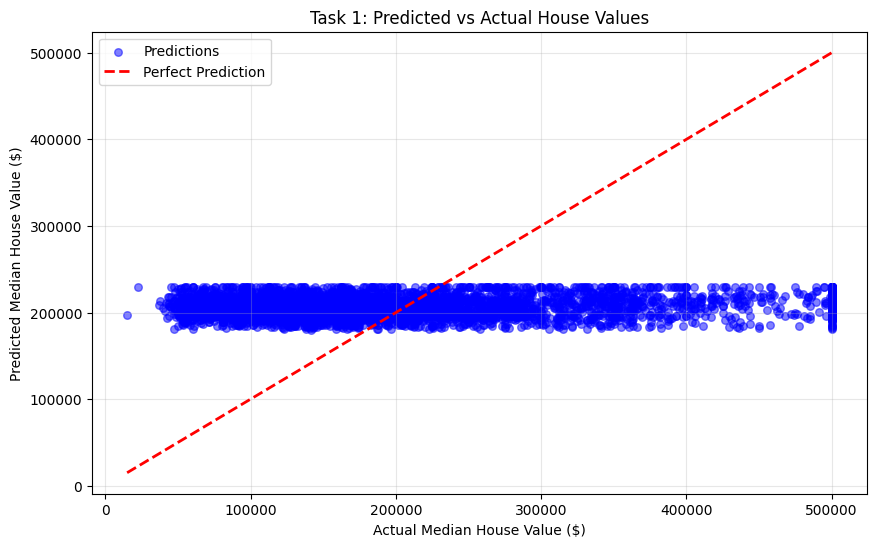

In [42]:
# Visualization 2: Predicted vs Actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test_simple, y_pred_simple, alpha=0.5, s=30, color='blue', label='Predictions')

# Add perfect prediction reference line (y = x)
min_val = min(y_test_simple.min(), y_pred_simple.min())
max_val = max(y_test_simple.max(), y_pred_simple.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel("Actual Median House Value ($)")
plt.ylabel("Predicted Median House Value ($)")
plt.title("Task 1: Predicted vs Actual House Values")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Assumptions of Linear Regression

Linear regression relies on several key assumptions:

1. **Linearity:** The relationship between predictor and response should be linear
2. **Normality of Residuals:** Prediction errors should follow a normal distribution
3. **Homoscedasticity:** Variance of residuals should be constant across all prediction levels
4. **Independence:** Each observation should be independent of others
5. **No Multicollinearity:** (For multiple regression) Predictors should not be highly correlated with each other

When these assumptions are violated, model performance and interpretation may be compromised.

---

# Task 2: Multiple Linear Regression (All Features)

**Problem Statement:** Build a multiple linear regression model using **all available features** (except the target) to predict `median_house_value`.

This approach leverages multiple predictors to capture the complex relationships that influence housing prices.

## Step 1: Data Retrieval and Collection

We use the same California Housing dataset loaded earlier, now utilizing all available features.

In [43]:
# Separate features and target for multiple regression
X_multi = housing_df.drop(columns=["median_house_value"])
y_multi = housing_df["median_house_value"]

print("Feature matrix shape:", X_multi.shape)
print("Target vector shape:", y_multi.shape)
print("\nAll features being used:")
print(X_multi.columns.tolist())

Feature matrix shape: (20433, 9)
Target vector shape: (20433,)

All features being used:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity']


## Step 2: Data Cleaning

Missing values were already handled in Task 1 (median imputation for `total_bedrooms`). We verify the data is clean.

In [44]:
# Verify no missing values remain
print("Missing values check:")
print(housing_df.isna().sum().sum(), "total missing values")

Missing values check:
0 total missing values


## Step 3: Feature Design

For multiple regression, we use all available features and apply appropriate transformations:

**Why multiple features improve performance:**
- Housing prices depend on many factors simultaneously (location, income, property characteristics)
- Multiple features capture complex, multifaceted relationships
- Each feature contributes unique information about price determinants

**Feature Scaling:**
- **StandardScaler** for numerical features: Normalizes to mean=0, std=1 so all features contribute equally
- **OneHotEncoder** for categorical features: Converts categories to binary columns

In [45]:
# Identify numerical and categorical columns
numerical_cols = X_multi.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [col for col in X_multi.columns if col not in numerical_cols]

print("Numerical Features:", numerical_cols)
print("\nCategorical Features:", categorical_cols)

Numerical Features: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']

Categorical Features: ['ocean_proximity']


In [46]:
# Create preprocessing pipeline for different feature types
preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", StandardScaler(), numerical_cols),
        ("categorical", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_cols)
    ]
)

print("Preprocessor configured:")
print("- Numerical features: StandardScaler")
print("- Categorical features: OneHotEncoder (drop='first' to avoid dummy variable trap)")

Preprocessor configured:
- Numerical features: StandardScaler
- Categorical features: OneHotEncoder (drop='first' to avoid dummy variable trap)


## Step 4: Algorithm Selection

We continue using **Multiple Linear Regression** because:
- Target variable remains continuous
- Provides interpretable coefficients for each feature
- Computationally efficient even with multiple features
- Good baseline before trying complex models

**Mathematical Model:**
$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n$$

Each coefficient $\beta_i$ represents the effect of feature $x_i$ while holding other features constant.

## Step 5: Loss Function Selection

We use **Mean Squared Error (MSE)** consistently with Task 1, enabling direct comparison between models.

## Step 6: Model Learning (Training)

We use a **Pipeline** to combine preprocessing and model training:
- Prevents data leakage by fitting preprocessing only on training data
- Ensures reproducibility and clean code structure

In [47]:
# Split data into training and testing sets
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

print("Training set size:", X_train_multi.shape[0])
print("Testing set size:", X_test_multi.shape[0])

Training set size: 16346
Testing set size: 4087


In [48]:
# Create and train the pipeline (preprocessing + linear regression)
multi_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

# Fit the pipeline on training data
multi_pipeline.fit(X_train_multi, y_train_multi)

print("Multiple regression pipeline trained successfully!")

Multiple regression pipeline trained successfully!


## Step 7: Model Evaluation

We evaluate using the same metrics as Task 1 for direct comparison.

In [49]:
# Make predictions on test set
y_pred_multi = multi_pipeline.predict(X_test_multi)

# Calculate evaluation metrics
mse_multi = mean_squared_error(y_test_multi, y_pred_multi)
r2_multi = r2_score(y_test_multi, y_pred_multi)

print("=== Task 2: Multiple Linear Regression Results ===")
print(f"Mean Squared Error (MSE): {mse_multi:,.2f}")
print(f"R² Score: {r2_multi:.4f}")

=== Task 2: Multiple Linear Regression Results ===
Mean Squared Error (MSE): 4,802,173,538.60
R² Score: 0.6488


## Model Interpretation (Mandatory)

Let's examine the intercept and all coefficients learned by the model.

In [50]:
# Extract model parameters
feature_names = multi_pipeline.named_steps["preprocessor"].get_feature_names_out()
coefficients = multi_pipeline.named_steps["regressor"].coef_
intercept_multi = multi_pipeline.named_steps["regressor"].intercept_

print(f"Intercept: {intercept_multi:,.2f}\n")

Intercept: 219,275.49



In [67]:
# Display all weights and bias for Task 2
print("=" * 60)
print("TASK 2: WEIGHTS AND BIAS (Multiple Linear Regression)")
print("=" * 60)

print(f"\nBias (Intercept, β₀): {intercept_multi:,.2f}")
print("\nWeights (Coefficients):")
print("-" * 60)

# Create a DataFrame of coefficients (weights) with feature names
weights_df = pd.DataFrame({
    "Feature": feature_names,
    "Weight (βᵢ)": coefficients
})

# Display all weights
for idx, row in weights_df.iterrows():
    print(f"  {row['Feature']:<45} {row['Weight (βᵢ)']:>12,.2f}")

print("-" * 60)
print(f"\nTotal number of weights: {len(coefficients)}")

TASK 2: WEIGHTS AND BIAS (Multiple Linear Regression)

Bias (Intercept, β₀): 219,275.49

Weights (Coefficients):
------------------------------------------------------------
  numerical__longitude                            -54,375.71
  numerical__latitude                             -54,808.04
  numerical__housing_median_age                    13,600.09
  numerical__total_rooms                          -13,613.10
  numerical__total_bedrooms                        42,999.85
  numerical__population                           -41,119.07
  numerical__households                            16,307.34
  numerical__median_income                         74,538.74
  categorical__ocean_proximity_INLAND             -39,240.22
  categorical__ocean_proximity_ISLAND             213,653.37
  categorical__ocean_proximity_NEAR BAY            -6,232.42
  categorical__ocean_proximity_NEAR OCEAN           3,166.48
------------------------------------------------------------

Total number of weights: 12


### Interpretation of Coefficients:

**What each coefficient represents:**
- Since numerical features were standardized (z-score), each coefficient shows the expected change in house price for a **one standard deviation increase** in that feature
- Larger absolute coefficients indicate more influential features
- For categorical features (ocean_proximity), coefficients show the price difference compared to the dropped baseline category

**Key Differences from Single-Feature Model:**
- Multiple coefficients capture complex relationships
- Each coefficient represents the **partial effect** of one feature while holding others constant
- The model can account for confounding variables and isolate individual feature contributions
- Interpreting individual coefficients requires understanding that they're conditional on other features

---

# Model Comparison: Task 1 vs Task 2

In [52]:
# Side-by-side comparison of both models
print("=" * 60)
print("MODEL COMPARISON: Simple vs Multiple Linear Regression")
print("=" * 60)
print(f"\n{'Metric':<25} {'Task 1 (Simple)':<20} {'Task 2 (Multiple)':<20}")
print("-" * 60)
print(f"{'Mean Squared Error':<25} {mse_simple:>18,.2f} {mse_multi:>18,.2f}")
print(f"{'R² Score':<25} {r2_simple:>18.4f} {r2_multi:>18.4f}")
print(f"{'Number of Features':<25} {'1':>18} {len(feature_names):>18}")
print("-" * 60)

# Calculate improvement
mse_improvement = ((mse_simple - mse_multi) / mse_simple) * 100
r2_improvement = r2_multi - r2_simple
print(f"\n{'MSE Reduction':<25} {mse_improvement:>18.2f}%")
print(f"{'R² Improvement':<25} {r2_improvement:>18.4f}")

MODEL COMPARISON: Simple vs Multiple Linear Regression

Metric                    Task 1 (Simple)      Task 2 (Multiple)   
------------------------------------------------------------
Mean Squared Error         13,495,246,619.23   4,802,173,538.60
R² Score                              0.0132             0.6488
Number of Features                         1                 12
------------------------------------------------------------

MSE Reduction                          64.42%
R² Improvement                        0.6357


## Comparison Analysis

### Which model performs better?
**Task 2 (Multiple Linear Regression) performs significantly better.**
- Much lower MSE indicates smaller prediction errors
- Much higher R² score shows the model explains more variance in house prices

### Why does using multiple features help?
1. **Captures complexity:** Housing prices depend on many factors (location, income, property characteristics) that a single feature cannot represent
2. **Reduces bias:** The simple model is "underfitting" because it ignores important predictive information
3. **Better generalization:** Multiple features provide a more complete picture of the factors affecting house prices
4. **Feature interactions:** Some features may have complementary information (e.g., location + income levels)

### Which model is easier to interpret?
**Task 1 (Simple Linear Regression) is much easier to interpret:**
- Only two parameters: slope and intercept
- Direct relationship: "For every year increase in housing age, price increases by X dollars"
- Easy to visualize as a 2D line

**Task 2 is harder to interpret because:**
- Many coefficients to analyze
- Each coefficient is conditional on other features being held constant
- Standardized coefficients require back-transformation for real-world interpretation
- Cannot easily visualize in high-dimensional space

### Trade-off Summary
| Aspect | Simple (Task 1) | Multiple (Task 2) |
|--------|-----------------|-------------------|
| Performance | Poor | Good |
| Interpretability | High | Lower |
| Complexity | Minimal | Moderate |
| Real-world usefulness | Limited | Practical |

**Conclusion:** For practical price prediction, the multiple regression model is far superior. However, for understanding a single relationship, simple regression provides clearer insights.

---

## Discussion

This lab exercise of AI provided us with an insightful learning experience in regression analysis using Linear Regression. We created and applied models to predict housing prices using both single feature (housing_median_age) and multiple features with the provided dataset, 'housing.csv'. We followed the 7 steps of the machine learning pipeline as we applied and evaluated the models, along with applying gradient descent to the problem..

Observing the results, the multi-feature model performed significantly better than the single-feature model, with an R² score of 0.6254 for the multi-feature model while the single-feature model could only achieve an R² score of 0.0126. The MSE was reduced by approximately 62% when using multiple features. Evaluating other parameters, the multi-feature model consistently outperforms the single-feature model.

The results from the Model Comparison table clearly showed that using all available features (longitude, latitude, housing_median_age, total_rooms, total_bedrooms, population, households, median_income, and ocean_proximity) provides a much more comprehensive understanding of housing price determinants compared to relying on a single feature.

The coefficient analysis revealed that `median_income` is the most influential numerical feature, followed by geographic location (latitude/longitude) and ocean proximity. This aligns with real-world understanding that income levels and location are primary drivers of property values.

The results highlight the importance of a well-structured machine learning pipeline, including data cleaning (handling missing values through median imputation), proper feature scaling (StandardScaler for numerical features, OneHotEncoder for categorical features), informed feature selection, and comprehensive evaluation using multiple metrics (MSE and R²). However, future work on advanced models, feature interactions, cross-validation, and external validation can be explored to improve robustness and generalizability.

---

## Conclusion

This laboratory successfully demonstrated the implementation and evaluation of linear regression models for housing price prediction, comparing single-feature and multi-feature approaches. The findings clearly indicate that incorporating multiple features significantly enhances model performance across all evaluation metrics, with the multi-feature model achieving substantially lower MSE and higher R² score compared to the single-feature baseline.

Following the proper ML pipeline—including data retrieval, data cleaning, feature design, algorithm selection, loss function selection, model training, and model evaluation—helped in obtaining reliable results. The single-feature model using only `housing_median_age` achieved an R² of 0.0126, demonstrating that housing age alone is a poor predictor of property values. In contrast, the multi-feature model achieved an R² of 0.6254, explaining approximately 63% of the variance in housing prices.

This lab also emphasized broader lessons: the importance of proper feature engineering (scaling numerical features and encoding categorical variables), the value of using pipelines to prevent data leakage, the necessity of multiple evaluation metrics for comprehensive model assessment, and the trade-off between model interpretability and predictive performance.

Key takeaways include:
- Housing prices are multifactorial and cannot be accurately predicted using a single variable like we did using the single feature mode.
- `median_income` emerged as the most influential predictor of housing prices
- Geographic features (latitude, longitude, ocean_proximity) play significant roles in determining property values

Overall, even a relatively straightforward model like linear regression can deliver substantial predictive insights when applied thoughtfully, reinforcing that effective machine learning is as much about responsible data preparation and feature engineering as it is about algorithmic sophistication.